# Customer Segmentation System

Cluster retail customers using RFM Analysis and K-Means Clustering.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [42]:
#Load Dataset
import pandas as pd

df = pd.read_csv(
    "../data/online_retail.csv",
    encoding="ISO-8859-1"
)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
#Dataset Shape
print("Rows and Columns:", df.shape)

#Columns Names
print("Column Names:", df.columns)


Rows and Columns: (541909, 8)
Column Names: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='str')


In [ ]:
#Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 69.3 MB


## 
The dataset contains transaction-level retail purchase records with customer, product, quantity, price, and invoice information.

In [9]:
#Summary Statistics
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [12]:
#Missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## 
Some CustomerID and Description values are missing. These will be handled during data cleaning.

In [13]:
#Duplicate Rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 5268


## 
Duplicate transactions are present and will be removed before analysis.

## Data Cleaning

In [14]:
# Remove Missing Customer IDs
df = df.dropna(subset=["CustomerID"])

In [15]:
# Remove Duplicates
df = df.drop_duplicates()

In [16]:
# Remove cancelled orders as they have negative values
df = df[df["Quantity"] > 0]

In [17]:
#Remove zero or Negative prices
df = df[df["UnitPrice"] > 0]

In [18]:
#Covert CustometID to Integer
df["CustomerID"] = df["CustomerID"].astype(int)

In [19]:
#Create total purchase amount
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

In [20]:
#Check cleaned dataset
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [21]:
#Final dataset shape
print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (392692, 9)


## 
Observation:
The dataset has been cleaned by removing missing values, duplicates, cancelled transactions, and invalid prices. A new TotalPrice feature has been created for RFM analysis.

## EDA


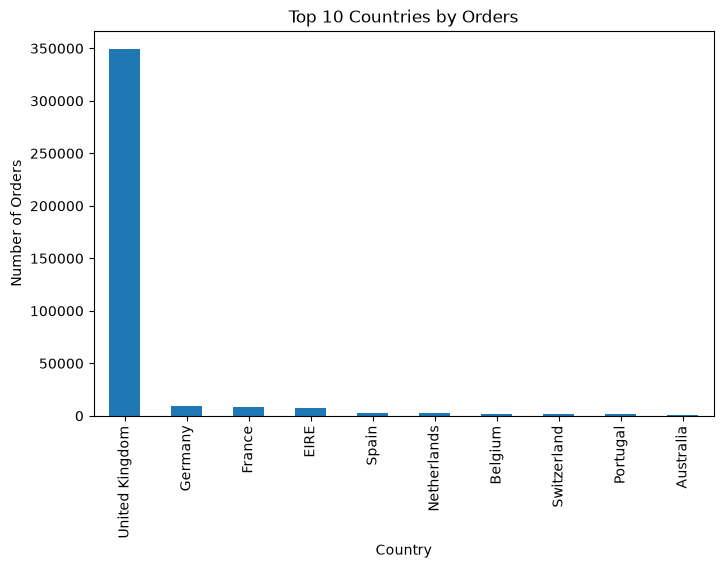

In [41]:
#Top 10 Countries by Number of Orders

import matplotlib.pyplot as plt

country_orders = df["Country"].value_counts().head(10)
plt.figure(figsize=(8,5))
country_orders.plot(kind="bar")
plt.title("Top 10 Countries by Orders")
plt.xlabel("Country")
plt.ylabel("Number of Orders")
plt.show()

## 
Observation: 
Most transactions come from a few countries, with the United Kingdom typically dominating the dataset.

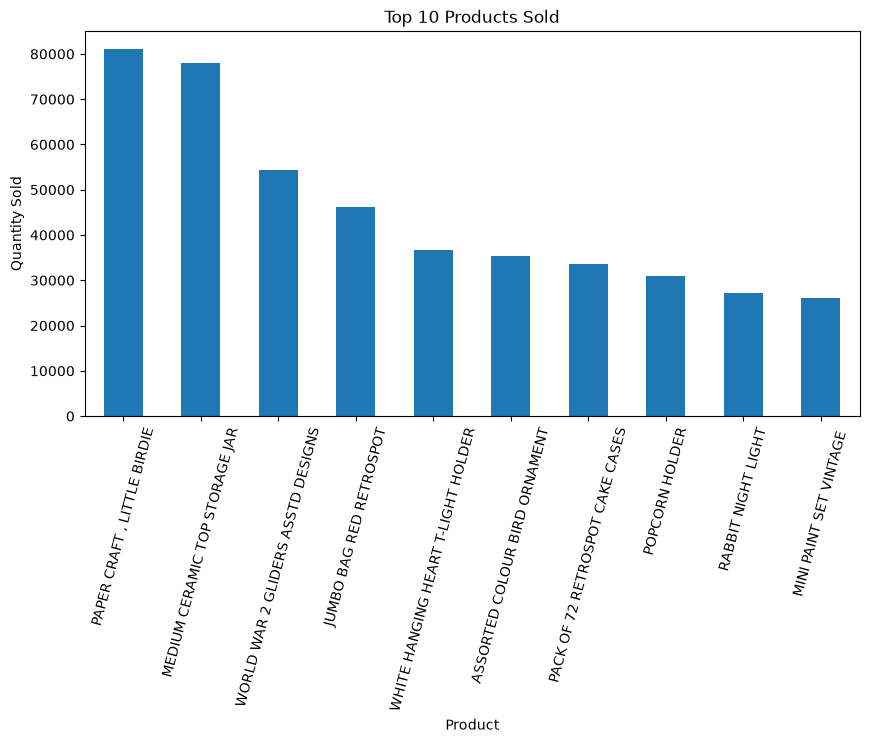

In [40]:
#Top 10 Products Sold
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind="bar")

plt.title("Top 10 Products Sold")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=75)
plt.show()

## 
Observation:
A small number of products contribute to a large portion of total sales volume.

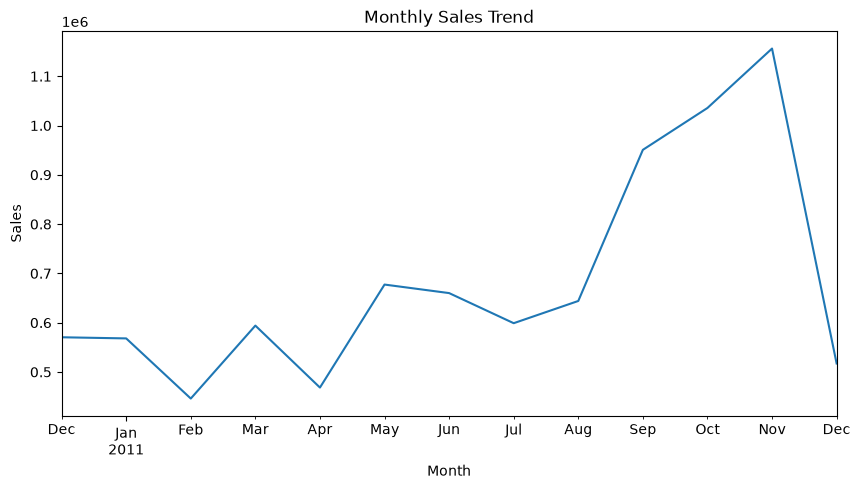

In [39]:
#Monthly Sales Trend

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Month"] = df["InvoiceDate"].dt.to_period("M")

monthly_sales = df.groupby("Month")["TotalPrice"].sum()
plt.figure(figsize=(10,5))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

## 
Observation: 
Sales fluctuate across months, showing seasonal purchasing patterns.

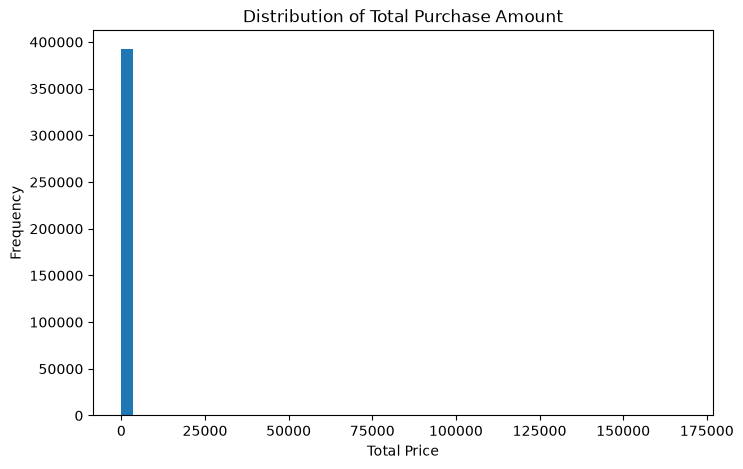

In [38]:
#Distribution of Total Purchase Amount

plt.figure(figsize=(8,5))
plt.hist(df["TotalPrice"], bins=50)
plt.title("Distribution of Total Purchase Amount")
plt.xlabel("Total Price")
plt.ylabel("Frequency")
plt.show()

## 
Observation: 
Most transactions are of relatively low value, while a few high-value purchases create a right-skewed distribution.

## RFM Analysis

RFM is a marketing technique used to understand customer behavior.

Recency (R): How recently did the customer make a purchase?                  
Frequency (F): How often does the customer purchase?                          
Monetary (M): How much money has the customer spent?

I will use RFM to identify loyal customers, at-risk customers, and high-value customers.

In [37]:
#Create Snapshot Date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(snapshot_date)

2011-12-10 12:50:00


## 
Observation: 
The latest transaction date is used as the reference point for calculating customer recency.

In [29]:
#Create RFM Table
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,2,7,4310.00
12348,75,4,1797.24
12349,19,1,1757.55
12350,310,1,334.40


## 
Observation: 
Each customer is summarized using Recency, Frequency, and Monetary metrics.

In [35]:
#Check Shape
print(rfm.shape)
rfm.describe()

(4338, 3)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


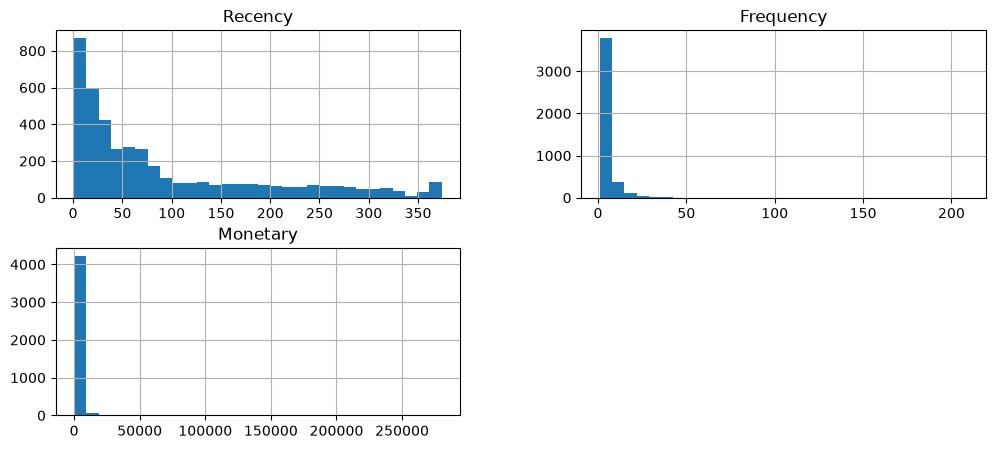

In [34]:
# Distribution of RFM Features
import matplotlib.pyplot as plt
rfm.hist(figsize=(12,5), bins=30)
plt.show()

## 
Observation: 
Customer purchase behavior is uneven, with many customers purchasing infrequently while a small group makes frequent, high-value purchases.

## Feature Scaling & K-Means Clustering
Recency may be around 300 days, while Monetary can be thousands of pounds.
Without scaling, Monetary would dominate the clustering.

In [33]:
#Standardize data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)
print(rfm_scaled.shape)

(4338, 3)


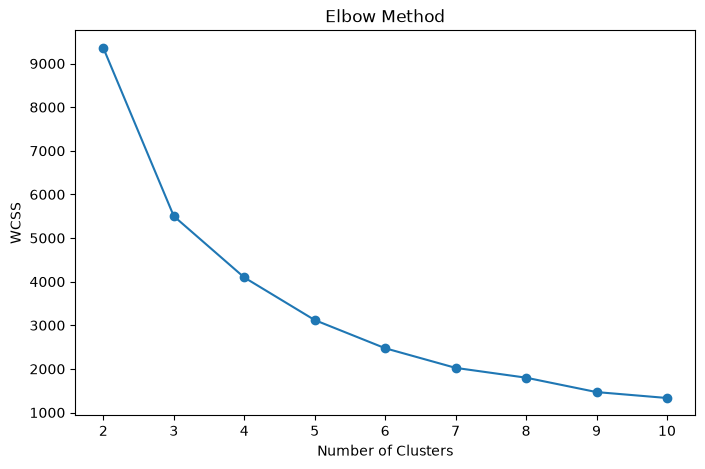

In [47]:
#Elbow Method
from sklearn.cluster import KMeans

wcss = []
for i in range(2,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(rfm_scaled)

    wcss.append(model.inertia_)

#Plot elbow curve

plt.figure(figsize=(8,5))
plt.plot(range(2,11), wcss, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

## 
Observation: 
The elbow point suggests an appropriate number of customer clusters. We will use four clusters for segmentation.

In [50]:
#Applying K- Means
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)
rfm.head()


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346,326,1,77183.60,3
12347,2,7,4310.00,0
12348,75,4,1797.24,0
12349,19,1,1757.55,0
12350,310,1,334.40,1


In [51]:
#Cluster counts
rfm["Cluster"].value_counts()

Cluster
0    3054
1    1067
3     204
2      13
Name: count, dtype: int64

In [52]:
#Cluster summary
cluster_summary = rfm.groupby("Cluster").mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,43.702685,3.682711,1353.625312
1,248.075914,1.552015,478.848773
2,7.384615,82.538462,127187.959231
3,15.500000,22.333333,12690.500392


## 
Observation:
Each cluster represents customers with distinct purchasing behavior based on recency, frequency, and spending.

## PCA Visualization
RFM has three dimensions.
PCA reduces it to two dimensions so we can visualize customer clusters.

In [53]:
#Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(rfm_scaled)

In [54]:
#Create PCA DataFrame
plot_df = pd.DataFrame({
    "PCA1": pca_components[:,0],
    "PCA2": pca_components[:,1],
    "Cluster": rfm["Cluster"]
})

plot_df.head()

,PCA1,PCA2,Cluster
CustomerID,,,
12346,4.107554,5.439993,3
12347,0.743044,-0.670756,0
12348,0.025230,-0.174675,0
12349,-0.027491,-0.734603,0
12350,-1.235593,1.834685,1


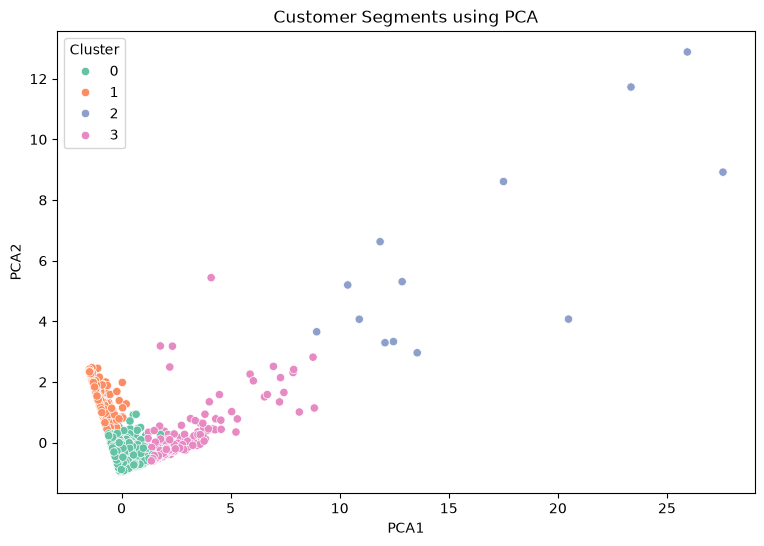

In [56]:
#PCA Scatter Plot
import seaborn as sns

plt.figure(figsize=(9,6))
sns.scatterplot(
    data=plot_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2"
)
plt.title("Customer Segments using PCA")
plt.show()

## 
Observation:
PCA provides a clear two-dimensional visualization of customer clusters, making the segmentation easier to interpret.

## Business Segments

In [57]:
#Give Business Names
segment_names = {
    0: "High Value Customers",
    1: "Regular Customers",
    2: "At Risk Customers",
    3: "Frequent Buyers"
}

rfm["Segment"] = rfm["Cluster"].map(segment_names)

rfm.head()

,Recency,Frequency,Monetary,Cluster,Segment
CustomerID,,,,,
12346,326,1,77183.60,3,Frequent Buyers
12347,2,7,4310.00,0,High Value Customers
12348,75,4,1797.24,0,High Value Customers
12349,19,1,1757.55,0,High Value Customers
12350,310,1,334.40,1,Regular Customers


In [59]:
#Segment counts
rfm["Segment"].value_counts()

Segment
High Value Customers    3054
Regular Customers       1067
Frequent Buyers          204
At Risk Customers         13
Name: count, dtype: int64

In [61]:
#Segment summary
segment_summary = rfm.groupby("Segment")[["Recency","Frequency","Monetary"]].mean()
segment_summary

,Recency,Frequency,Monetary
Segment,,,
At Risk Customers,7.384615,82.538462,127187.959231
Frequent Buyers,15.500000,22.333333,12690.500392
High Value Customers,43.702685,3.682711,1353.625312
Regular Customers,248.075914,1.552015,478.848773


## 
Observation:
Business-friendly segment names help marketing teams identify customer groups for targeted campaigns and retention strategies.

In [62]:
#Save Outputs
import os
import joblib

os.makedirs("../outputs", exist_ok=True)
os.makedirs("../models", exist_ok=True)

rfm.to_csv(
    "../outputs/customer_segments.csv",
    index=True
)

segment_summary.to_csv(
    "../outputs/segment_summary.csv"
)

joblib.dump(
    kmeans,
    "../models/customer_segmentation_model.pkl"
)

print("Project Completed Successfully!")

Project Completed Successfully!
